# 分块搭建工作

## 前向传播过程

### 建立一层神经元

注：使用行向量+广播机制，即输出$\vec{z}^T= \vec{x}^T W + \vec{b}$，这样$z$就可以包含多个batch，变成矩阵$Z$，共用一个$\vec b$，因为 **$\vec{b}$ 会自动进行广播**。

$$Z = XW + \vec 1 \vec b$$

注：$\vec b$为行向量，$\vec 1$为列向量

In [ ]:
import numpy as np
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.zeros(output_dim)
        
    def forward(self, x):
        z = x @ self.W + self.b
        return z

#### *test*

In [9]:
layer=LinearLayer(3,4)
input = np.array([[2,3,4],
         [3,4,5]])
z=layer.forward(input)
print(z)

[[-4.70039951 -2.92790095  5.06622023  5.92585631]
 [-5.87292075 -4.38847719  6.75256716  7.44759927]]


### 建立神经元处的ReLU函数

将 ReLU 封装成一个对象（Class），我们就可以利用它的 **属性（Attributes）** 来保存“历史状态”。

在前向传播 forward 时，我们把 $x > 0$ 的信息存到比如 self.mask 里；

在反向传播 backward 时，我们再把 self.mask 拿出来用。这就好比在演化的路径上留下了“记忆节点”。

In [ ]:
class ReLU:
    def __init__(self):
        self.mask = None
        
    def forward(self, z):
        self.mask = (z>0)
        return z * self.mask

#### *test*

In [ ]:
relu=ReLU()
z=np.array([-1,2,3])
print(relu.forward(z))
print(relu.mask)

[0 2 3]
[False  True  True]


### 建立损失函数

为了给未来的 backward（反向传播）打个伏笔：

计算梯度时，我们需要用到前向传播时的预测值 $\hat{Y}$ 和真实值 $Y$。因此，在 forward 中，除了计算出具体的 Loss 数值外，需要把传入的 $Y$ 和 $\hat{Y}$ 作为属性保存下来。

$$L=\frac{1}{N} \sum _{i=1} ^N (\hat{y_i}-y_i)^2$$

In [ ]:
class MSELoss:
    def __init__(self):
        self.y_true = None
        self.y_pred = None
        
    def forward(self, y_pred, y_true):
        self.y_true = y_true
        self.y_pred = y_pred
        loss = np.mean((y_pred-y_true)**2)
        return loss
    

#### *test*

In [23]:
l=MSELoss()
y_true = np.array([[1,2,3],
            [4,5,6]])
y_pred = np.array([[2,3,4],
                [3,4,4]])
print(l.forward(y_pred, y_true))
print(y_true.size)

1.5
6


## 反向传播过程

### 梯度从损失函数出发

求出 Loss 对 $\hat{Y}$ 的偏导数 $$\frac{\partial L}{\partial \hat{Y}} = \frac{2}{N} (\hat{Y}-Y) $$ 

In [ ]:
class MSELoss:
    def __init__(self):
        self.y_true = None
        self.y_pred = None

    def forward(self, y_pred, y_true):
        self.delta_y = y_pred-y_true
        loss = np.mean(self.delta_y **2)
        return loss
    
    def backward(self):
        grad = 2/self.delta_y.size * self.delta_y
        return grad

### 梯度通过ReLU函数

ReLU的导数$$\left[ \frac{\partial}{\partial X} \text{ReLU}(X) \right]_{ij} = \begin{cases} 1 & \text{if } X_{ij} > 0 \\ 0 & \text{if } X_{ij} \le 0 \end{cases}$$

In [ ]:
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, z):
        self.mask = (z>0)
        return z * self.mask
    
    def backward(self, input_grad):
        return input_grad * self.mask

### 梯度通过一层神经元

关键：当你把反向传播的梯度 $\frac{\partial L}{\partial Z}$ 传回到 LinearLayer 时，这个层和 ReLU 不同。ReLU 只需要把力传给上一层就完事了，但 LinearLayer 必须利用这个力做三件事：
1. 算出给上一层的力 $\frac{\partial L}{\partial X}$ ：好让网络更前面的层继续反向传播。
   
2. 算出给自己权重 W 的修正力 $\frac{\partial L}{\partial W}$ ：用来更新 W。
   
3. 算出给自己偏置 b 的修正力 $\frac{\partial L}{\partial \vec b}$ ：用来更新 $\vec b$。

矩阵大小：
$$Z:batch \times output$$
$$X:batch \times input$$
$$W:input \times output$$
$$\vec b:1 \times output$$
$$\vec 1:batch \times 1$$

由于$Z = XW + \vec 1 \vec b$，并且需要大小匹配，故有：
$$\frac{\partial L}{\partial X}=\frac{\partial L}{\partial Z} W^T$$
$$\frac{\partial L}{\partial W}=X^T \frac{\partial L}{\partial Z}$$
$$\frac{\partial L}{\partial \vec b}= \vec 1 ^T \frac{\partial L}{\partial Z}$$

In [ ]:
# test np.sum()
z=[[1,2,3],
   [4,5,6]]
print(np.sum(z, axis=0))

[5 7 9]


对于$\vec 1 ^T \frac{\partial L}{\partial Z}$，在 NumPy 中不需要真的去造一个全 1 的向量再相乘，而是可以直接使用张量求和函数：np.sum(z, axis=0)。这里的 axis=0 意味着沿着批次（样本）的维度把梯度全加起来，完美契合公式。

In [ ]:
import numpy as np
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.zeros(output_dim)

    def forward(self, x):
        self.x = x
        z = x @ self.W + self.b
        return z
    
    def backward(self, grad_z):
        grad_x = grad_z @ self.W.T
        self.grad_W = self.x.T @ grad_z
        self.grad_b = np.sum(grad_z, axis=0)
        return grad_x


### 神经元参数更新

刚才算出的梯度 grad_W ($\frac{\partial L}{\partial W}$)，是指向Loss增加最快方向的向量。

为了让Loss极小化，必须往**负梯度**的方向移动。

在数值计算中，我们通过一个离散的步长（标量 $\eta$ ）来更新状态，这个步长是**人为设定**的，且对$W$和$\vec b$是相同的（因为梯度自带”分配比例“）

$$W_{new} = W_{old} - \eta \frac{\partial L}{\partial W}$$
$$\vec b_{new} = \vec b_{old} - \eta \frac{\partial L}{\partial \vec b}$$

In [ ]:
import numpy as np
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.zeros(output_dim)
        self.x = None
        self.grad_W = None
        self.grad_b = None

    def forward(self, x):
        self.x = x
        z = x @ self.W + self.b
        return z
    
    def backward(self, grad_z):
        grad_x = grad_z @ self.W.T
        self.grad_W = self.x.T @ grad_z
        self.grad_b = np.sum(grad_z, axis=0)
        return grad_x
    
    def update(self, learning_rate):
        self.W -= learning_rate * self.grad_W
        self.b -= learning_rate * self.grad_b

# 开始集成为神经网络

## 先摆上所有零件

### 网络零件

In [36]:
import numpy as np
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = np.random.randn(input_dim, output_dim)
        self.b = np.zeros(output_dim)
        self.x = None
        self.grad_W = None
        self.grad_b = None

    def forward(self, x):
        self.x = x
        z = x @ self.W + self.b
        return z
    
    def backward(self, grad_z):
        grad_x = grad_z @ self.W.T
        self.grad_W = self.x.T @ grad_z
        self.grad_b = np.sum(grad_z, axis=0)
        return grad_x
    
    def update(self, learning_rate):
        self.W -= learning_rate * self.grad_W
        self.b -= learning_rate * self.grad_b

class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, z):
        self.mask = (z>0)
        return z * self.mask
    
    def backward(self, input_grad):
        return input_grad * self.mask
    
    # 为了方法名称一致以便于多态调用，加入update方法
    def update(self, learning_rate):
        pass


### 损失函数评估零件

In [37]:
class MSELoss:
    def __init__(self):
        self.y_true = None
        self.y_pred = None

    def forward(self, y_pred, y_true):
        self.delta_y = y_pred-y_true
        loss = np.mean(self.delta_y **2)
        return loss
    
    def backward(self):
        grad = 2/self.delta_y.size * self.delta_y
        return grad

## 再写集成主板

外部调用应是如下形式：
```
my_components = [
    LinearLayer(input_dim=2, output_dim=4),
    ReLU(),
    LinearLayer(input_dim=4, output_dim=1)
]
my_net = NeuralNetwork(my_components)

my_loss = MSELoss()

learning_rate = 0.01

for epoch in range(100): # 实验迭代 100 次
    # --- 前向演化 ---
    y_pred = my_net.forward(X)
    
    # --- 能量评估 ---
    loss_value = my_loss.forward(y_pred, y_true)
    
    # --- 产生拉回力 (梯度起爆) ---
    grad_from_loss = my_loss.backward()
    
    # --- 时间反演 (误差回传) ---
    my_net.backward(grad_from_loss)
    
    # --- 系统参数坍缩/更新 ---
    my_net.update(learning_rate)

```

### 集成多层LinearLayer和ReLU的神经网络

In [38]:
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for unit in self.layers:
            x = unit.forward(x)
        return x

    def backward(self, grad):
        for unit in self.layers[::-1]:
            grad = unit.backward(grad)
        return grad
    
    def update(self, learning_rate):
        for unit in self.layers:
            unit.update(learning_rate)
            

# 正式实例化

## 真实数据生成

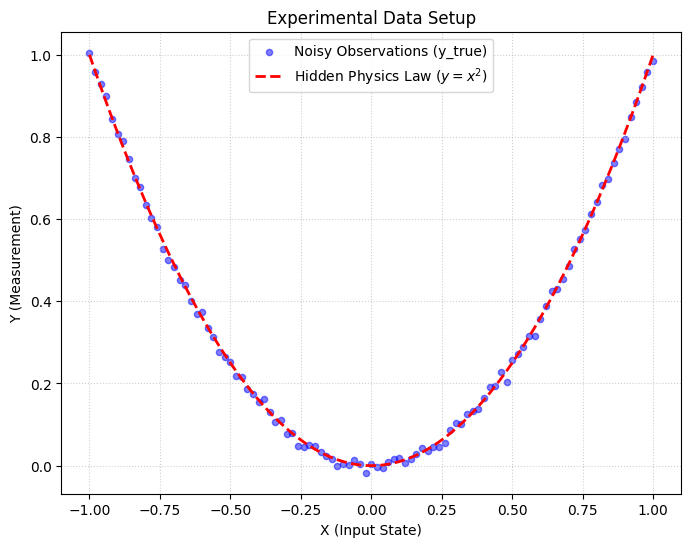

In [52]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
x_data = np.linspace(-1,1,101).reshape(-1,1) # 把行向量变为列向量，batch=100（同时观察100个粒子），input=1（每个粒子有1个自由度需要观测）
y_ideal = x_data **2
noise = 0.01 * np.random.randn(101,1)
y_true = y_ideal + noise
plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_true, color='blue', alpha=0.5, s=20, label='Noisy Observations (y_true)')
plt.plot(x_data, y_ideal, color='red', linestyle='--', linewidth=2, label='Hidden Physics Law ($y=x^2$)')
plt.xlabel("X (Input State)")
plt.ylabel("Y (Measurement)")
plt.title("Experimental Data Setup")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 主程序

0.00020689847950703904


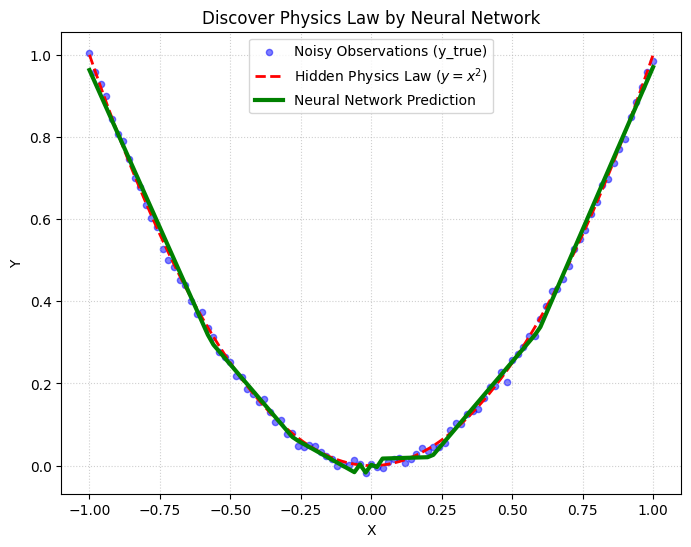

In [79]:
layers = [LinearLayer(1, 50), ReLU(), LinearLayer(50, 10), LinearLayer(10, 1)]
my_net = NeuralNetwork(layers)
my_loss = MSELoss()
learning_rate = 0.001

for _ in range(10000):
    y_pred = my_net.forward(x_data)
    loss = my_loss.forward(y_pred, y_true)
    grad_from_loss = my_loss.backward()
    my_net.backward(grad_from_loss)
    my_net.update(learning_rate)

y_final_pred = my_net.forward(x_data)
print(loss)

plt.figure(figsize=(8, 6))
plt.scatter(x_data, y_true, color='blue', alpha=0.5, s=20, label='Noisy Observations (y_true)')
plt.plot(x_data, y_ideal, color='red', linestyle='--', linewidth=2, label='Hidden Physics Law ($y=x^2$)')
plt.plot(x_data, y_final_pred, color='green', linewidth=3, label='Neural Network Prediction')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Discover Physics Law by Neural Network")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
